# **DATA LOADING**

In [1]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

### **Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import requests
# pip install umap-learn
import umap.umap_ as umap
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from collections import Counter
from skimage.feature import hog
from sklearn.metrics import  precision_score, recall_score, f1_score

from cuml.linear_model import LogisticRegression as cuMLLogisticRegression
from cuml.metrics import accuracy_score,confusion_matrix
from cuml.preprocessing import MinMaxScaler
import cupy as cp
import time
from cuml.svm import LinearSVC
from cuml.svm import SVC

In [3]:
# Link raw GitHub
train_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-images-idx3-ubyte'
train_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-labels-idx1-ubyte'
test_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte'
test_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte'

# Function to download files from a URL
def download_file(url, filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)

# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Tải dữ liệu từ GitHub
download_file(train_images_url, 'train-images-idx3-ubyte')
download_file(train_labels_url, 'train-labels-idx1-ubyte')
download_file(test_images_url, 't10k-images-idx3-ubyte')
download_file(test_labels_url, 't10k-labels-idx1-ubyte')

# Loading training data
train_images = load_images('train-images-idx3-ubyte')
train_labels = load_labels('train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('t10k-images-idx3-ubyte')
test_labels = load_labels('t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


#  **Exploratory Data Analysis (EDA)**

### **Show Some Image of each Class**

In [ ]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

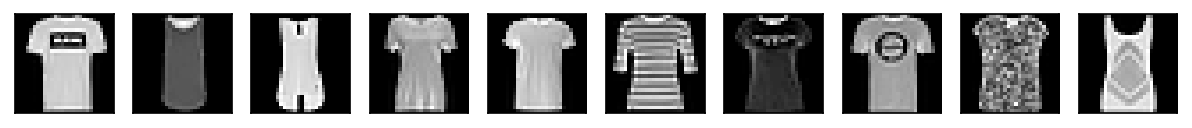

'label 1'

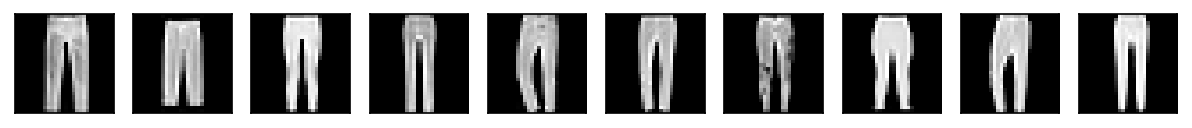

'label 2'

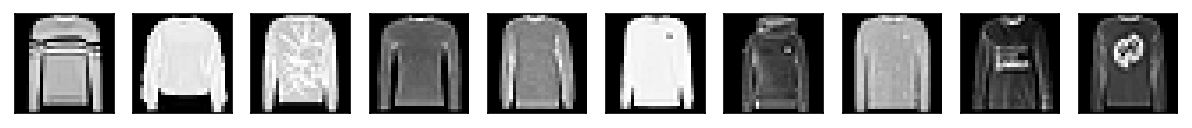

'label 3'

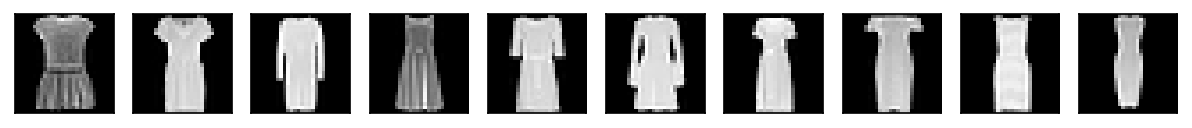

'label 4'

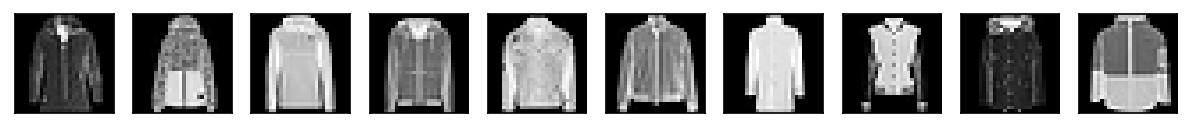

'label 5'

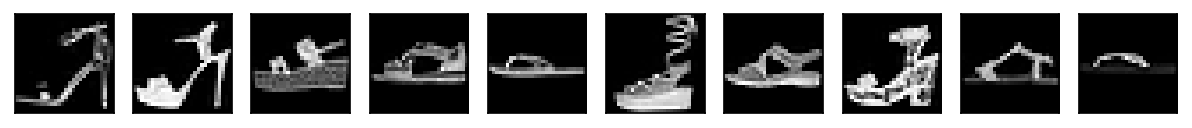

'label 6'

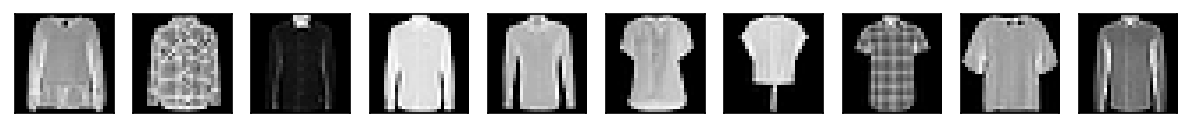

'label 7'

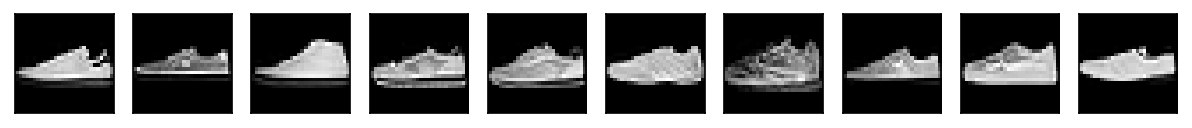

'label 8'

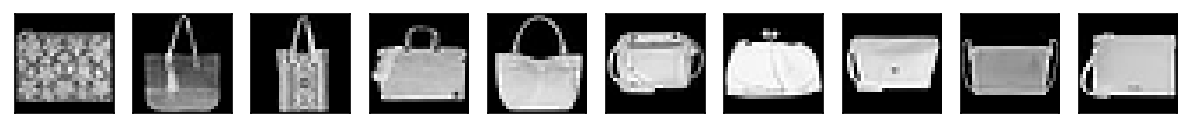

'label 9'

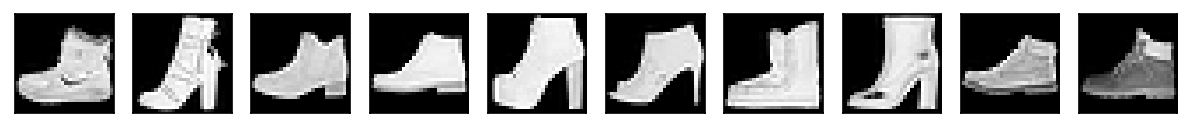

In [ ]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

### **Frequency of the data**

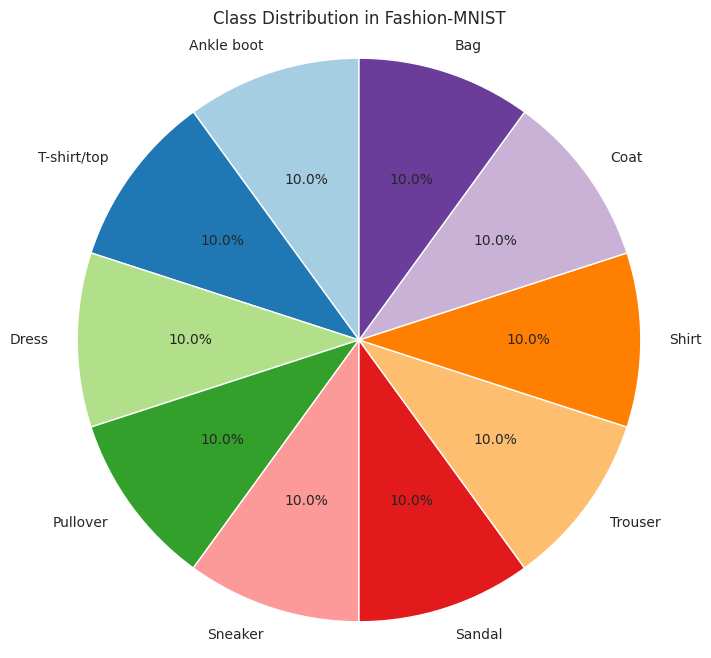

In [6]:
# List of class names for the train_images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors) # using pie chart
    plt.title('Class Distribution in Fashion-MNIST')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
class_distribution(train_labels)

> The number of each layer is the same => **The dataset is balanced**


---



### **Visualization using UMAP**


> **UMAP (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique that is particularly effective for visualizing high-dimensional data. It is based on manifold learning techniques and topological data analysis.**

> **Using UMAP on Fashion MNIST can help in visualizing the high-dimensional pixel data in a 2D space, making it easier to understand the distribution and clustering of different fashion items.**

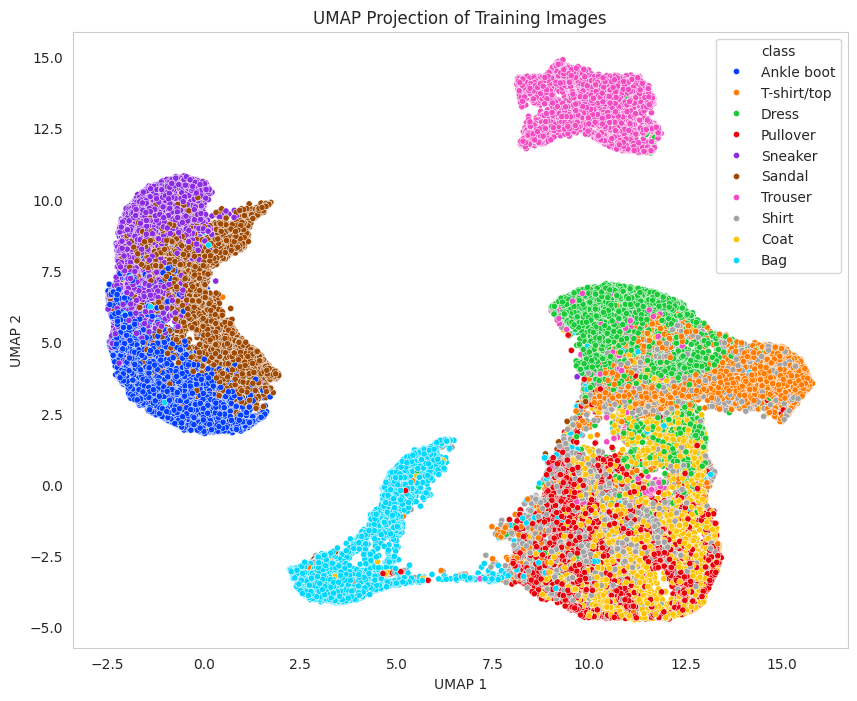

In [5]:
# Apply UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
train_images_umap = reducer.fit_transform(train_images)

# Create DataFrame
df = pd.DataFrame(train_images_umap, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels using class_names list
df["class"] = df["class"].apply(lambda x: class_names[x])

# Visualize the results with vibrant colors
sns.set_style("whitegrid", {'axes.grid': False})
palette = sns.color_palette("bright", 10)  # Use a bright color palette
plt.figure(figsize=(10, 8))
sns.scatterplot(x="x", y="y", hue="class", palette=palette, data=df, legend='full', s=20)  # Adjust `s` as needed
plt.title('UMAP Projection of Training Images')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()


- **Clear clusters:** Classes like Ankle boot, T-shirt/top, and Trouser form clear, distinct clusters, making them easier for the model to classify.

- **Overlap between classes:** Dress, Pullover, and Coat show overlap, indicating similar features that could lead to misclassification.

- **Scattered distribution:** Sneaker and Bag are scattered, suggesting diverse samples that might make classification more challenging for the model.

> This UMAP projection provides insights into class similarities and separability, emphasizing that while most classes form distinct clusters, some visually similar classes exhibit overlap. This shows that with linear models (such as Logistic Regression), it will require more complex and challenging processing to separate these classes.


---



### **Pixel Distribution of each Class**


> We need to examine the pixel distribution for each class because some classes may have more dark pixels (low values), while others have more bright pixels (high values). This information helps us better understand the image structure of each class.





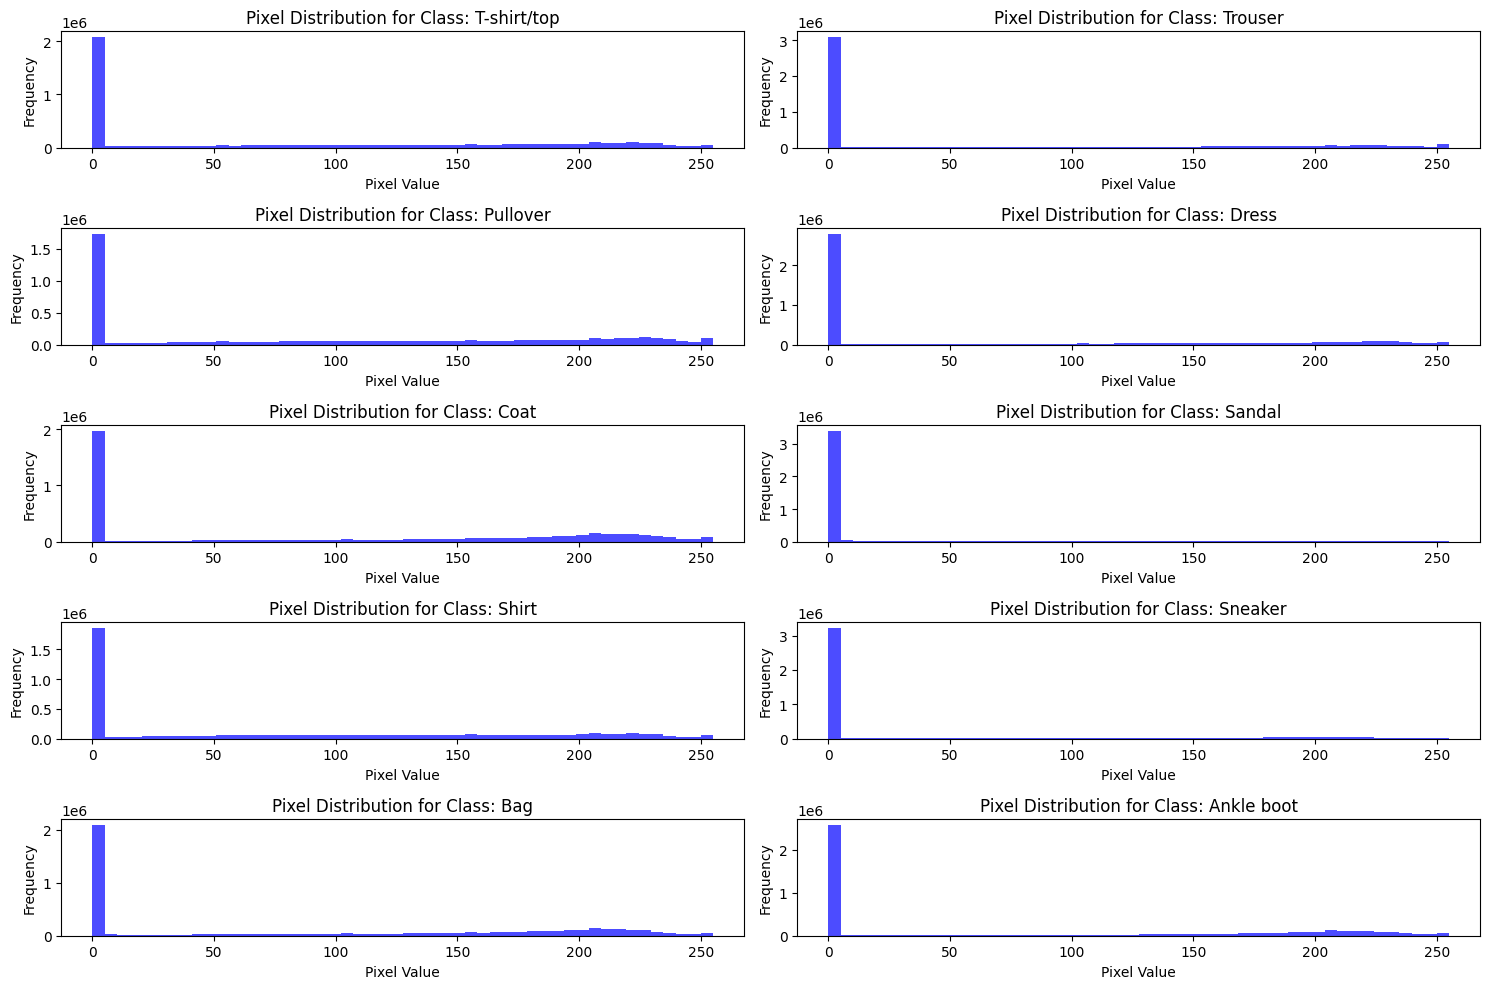

In [ ]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images, train_labels, class_names)


>We can see **values .0** that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.


---



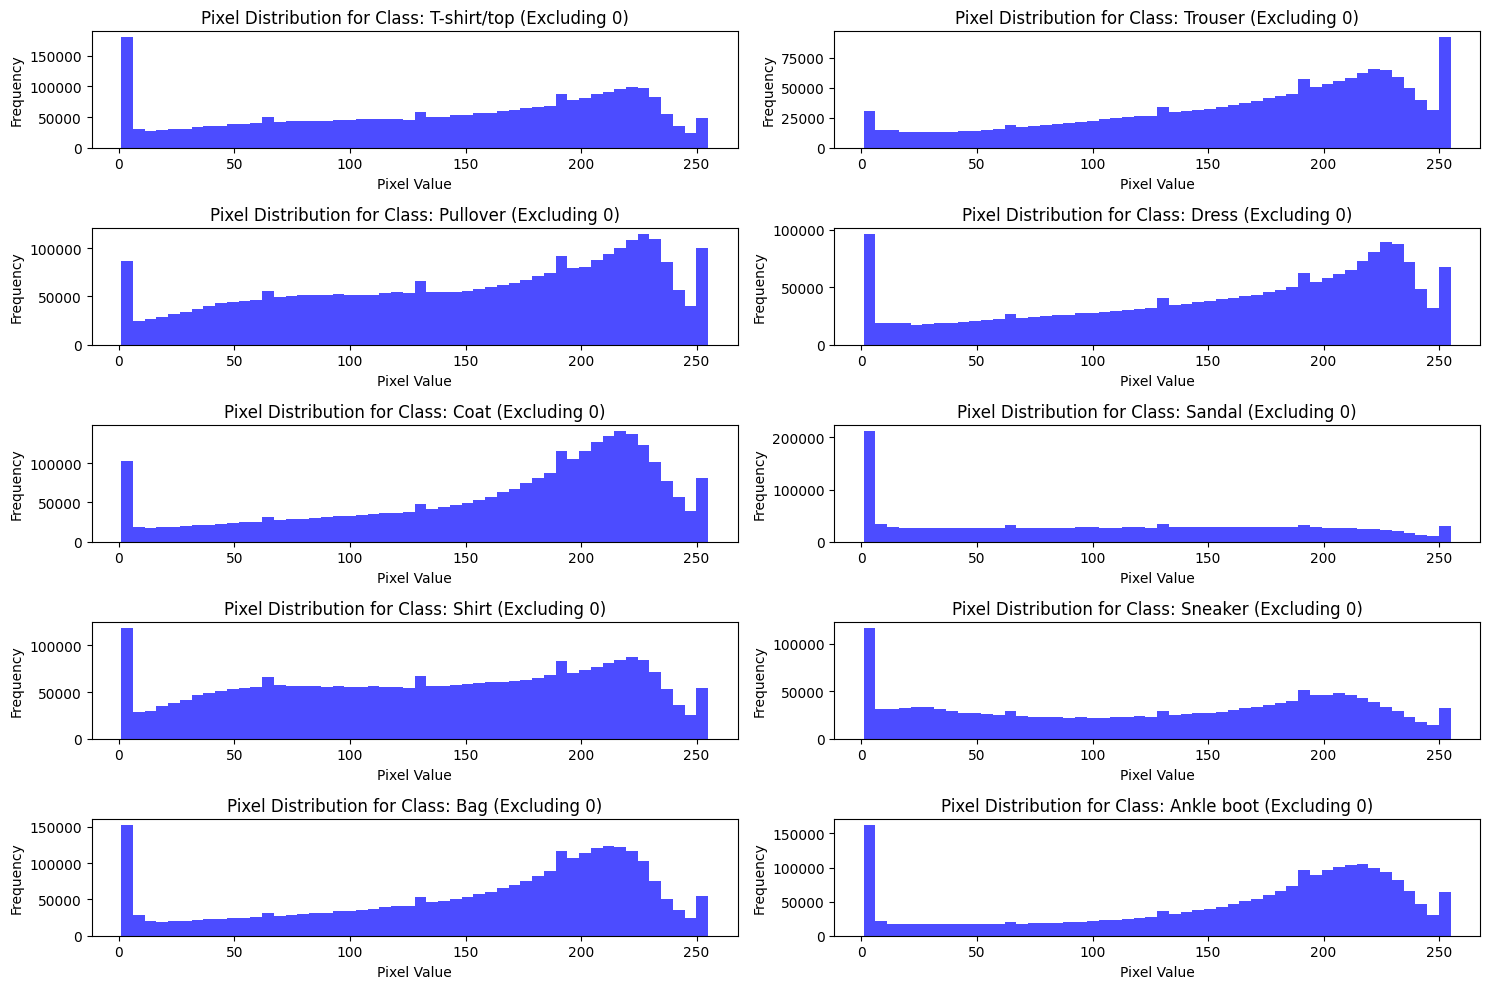

In [ ]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images, train_labels, class_names)

### **Pixel Intensity Distribution Analysis by Class**
- #### **Classes with Similar Intensity Distribution:**

> In general, the classes “T-shirt/top,” “Pullover,” “Coat,” and “Shirt” have
relatively even pixel intensity distributions, with many pixels concentrated at higher intensities (around 0.7 to 1). This could be due to the uniform color and minimal detail in these clothing items compared to other classes.

- #### **Class with Lower Intensity Concentration:**

> The classes “Sandal” and “Sneaker” show lower pixel intensity distributions at high values, indicating more pixels in darker or grayish regions. This likely reflects the footwear characteristics in the dataset, as they tend to have larger dark or solid-colored areas.

- #### **Classes “Bag” and “Ankle Boot”:**

> Both of these classes have a similar pixel distribution, with intensities higher around values between 0.5 and 1. This may be due to the shapes of bags and boots, which cover more of the frame, resulting in more high-intensity pixels.

- #### **Class “Trouser”:**

>This class has a distinct distribution, with a concentration of pixels at intensities close to 1, indicating that trousers in the dataset tend to have uniform and brighter colors in many areas, particularly along the pant legs.

---



### **Heat map for correlation label**

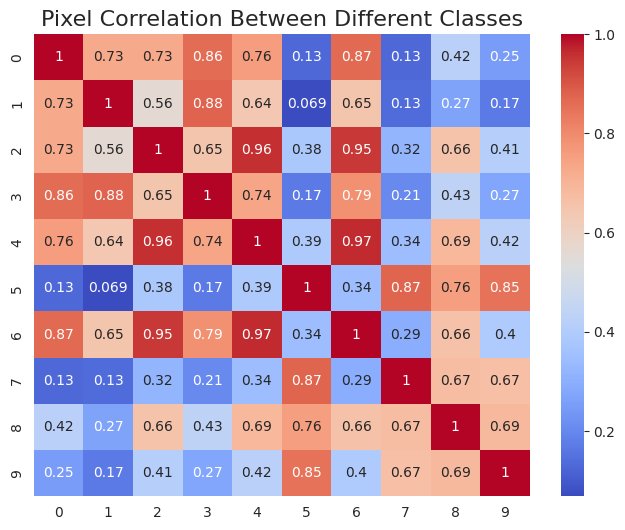

In [10]:
# Built correlation matrix

class_images = {label: train_images[train_labels == label] for label in range(10)}

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

- #### **High Correlation Between Certain Classes:**

> Some classes have a high correlation with each other, such as class 0 (T-shirt/top) and class 3 (Dress), as well as class 2 (Pullover) and class 4 (Coat),... This may be due to these classes having similar styles or characteristics, leading to similar pixel distributions.

- #### **Low Correlation Between Other Classes:**

> Classes like 1 (Trouser) and 5 (Sandal) have lower correlations with other classes, clearly reflecting differences in pixel structure. This is reasonable, as images in these classes have distinct shapes and features (e.g., trousers and footwear).

- ***Conclusion: The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes. This helps determine the appropriate classification method, especially when there are multiple highly correlated classes (One-vs-Rest or Softmax).***


---




# P**REPROCESSING**

In [ ]:
# Convert data from numpy array to cupy array to use GPU
train_images = cp.asarray(train_images)
train_labels = cp.asarray(train_labels,dtype=cp.int32)
test_images = cp.asarray(test_images)
test_labels = cp.asarray(test_labels, dtype=cp.int32)

In [ ]:
# Scale
scaler = MinMaxScaler()
train_images = scaler.fit_transform(train_images)
test_images = scaler.fit_transform(test_images)

# **Model Training**

> **Method and Libraries:** Use cuML instead of scikit-learn to enable GPU-accelerated training. As part of NVIDIA’s RAPIDS AI suite, cuML speeds up model training on large datasets by leveraging GPU power, which scikit-learn doesn’t support.

> **Processing Unit:** use GPU T4 x2 on Kaggle


---



## **Linear Model - LogisticRegression**

### **Parameter**

**`solver: ‘qn’ (default=’qn’)`**

> Algorithm to use in the optimization problem. Currently only qn is supported, which automatically selects either L-BFGS or OWL-QN depending on the conditions of the l1 regularization described above.

**`max_iter: int (default = 1000)`**

> Maximum number of iterations taken for the solvers to converge.

**`penalty: ‘none’, ‘l1’, ‘l2’, ‘elasticnet’ (default = ‘l2’)`**

> Used to specify the norm used in the penalization. If ‘none’ or ‘l2’ are selected, then L-BFGS solver will be used. If ‘l1’ is selected, solver OWL-QN will be used. If ‘elasticnet’ is selected, OWL-QN will be used if l1_ratio > 0, otherwise L-BFGS will be used.

**`fit_intercept: boolean (default = True)`**

> If True, the model tries to correct for the global mean of y. If False, the model expects that you have centered the data.

**`C: float (default = 1.0)`**

> Inverse of regularization strength; must be a positive float.


---




### **Softmax Regression**

> **cuML’s LogisticRegression can take array-like objects, either in host as NumPy arrays or in device (as Numba or __cuda_array_interface__ compliant), in addition to cuDF objects. It provides both single-class (using sigmoid loss) and multiple-class (using softmax loss) variants, depending on the input variables.**

In [ ]:
# Train Logistic Regression with multiple-class (Softmax Regression)
softmax_model = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_model.fit(train_images, train_labels)
end_time = time.time()

# Calculate training time
softmax_training_time = end_time - start_time

Training time: 67.12s
Accuracy: 0.8438
Precision: 0.8426
Recall: 0.8438
F1 Score: 0.8430


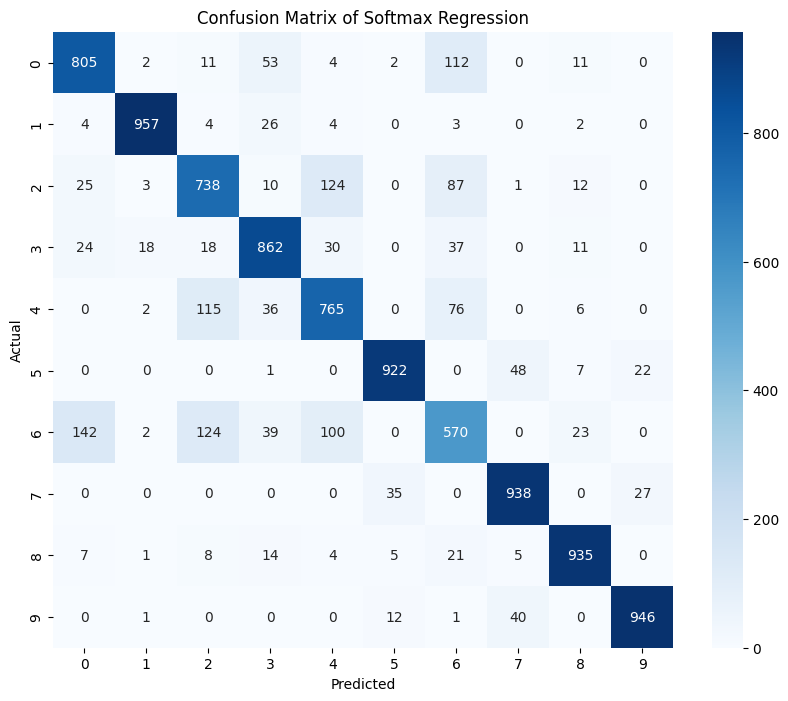

In [ ]:
# Make predict on test-set
test_predictions = softmax_model.predict(test_images)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_accuracy = accuracy_score(test_labels, test_predictions)
softmax_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_training_time:.2f}s")
print(f"Accuracy: {softmax_accuracy:.4f}")
print(f"Precision: {softmax_precision:.4f}")
print(f"Recall: {softmax_recall:.4f}")
print(f"F1 Score: {softmax_f1:.4f}")

# Confusion matrix
softmax_conf_matrix = confusion_matrix(test_labels, test_predictions)
softmax_conf_matrix = cp.asnumpy(softmax_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(softmax_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Softmax Regression')
plt.show()

#### **Observation from Score:**

* The accuracy of the model is 84.40%, which means the model correctly predicts 84.40% of the samples in the test set. This is a pretty good result, indicating that the model is quite accurate in classifying the classes.
* The precision is 84.28%, meaning that 84.28% of the model's positive predictions are correct.
* The recall is 84.40%, meaning the model can identify 84.40% of the actual positive samples from all the positive samples.
* The F1 Score is 84.32%, which is the harmonic mean of precision and recall. The high value of the F1 Score (84.32%) indicates that the model performs well on both aspects.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(softmax_conf_matrix.shape[0]):
    correct_predictions = softmax_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 958 correctly classified samples.
Class 'Sandal' has 921 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 935 correctly classified samples.
Class 'Ankle boot' has 947 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(softmax_conf_matrix.shape[0]):
    for predicted_class in range(softmax_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 123 samples
Actual class 'Coat' misclassified as 'Pullover': 114 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 124 samples
Actual class 'Shirt' misclassified as 'Coat': 101 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'


---



### **With Logistic Regression, we have two strategies for multi-label classification:**:

* **One-Vs-One:** In this approach, for each pair of different classes, we create a binary classifier to distinguish between them, then use voting to determine the winning class. Finally, we choose the class with the most votes as the predicted class for the data point.
> This strategy helps reduce misclassification by comparing each pair of classes individually. However, it requires creating a large number of classifiers and may result in redundant classifiers.

* **One-Vs-Rest:** Here, we create classifiers between one class and all other classes, then select the class with the highest probability as the predicted class for the data point
> This strategy reduces the number of classifiers and computational complexity. However, it may produce poor results if there is a large imbalance in class labels or if data points are not clearly distinguishable from the rest.


---




### **Logistic Regression (One vs Rest)**

In [ ]:
from cuml.multiclass import OneVsOneClassifier, OneVsRestClassifier

Training time :  22.349
Accuracy : 0.8413000106811523
Precision score : 0.8392065145395318 
Recall score: 0.8413
F1 score : 0.8396281204786742 


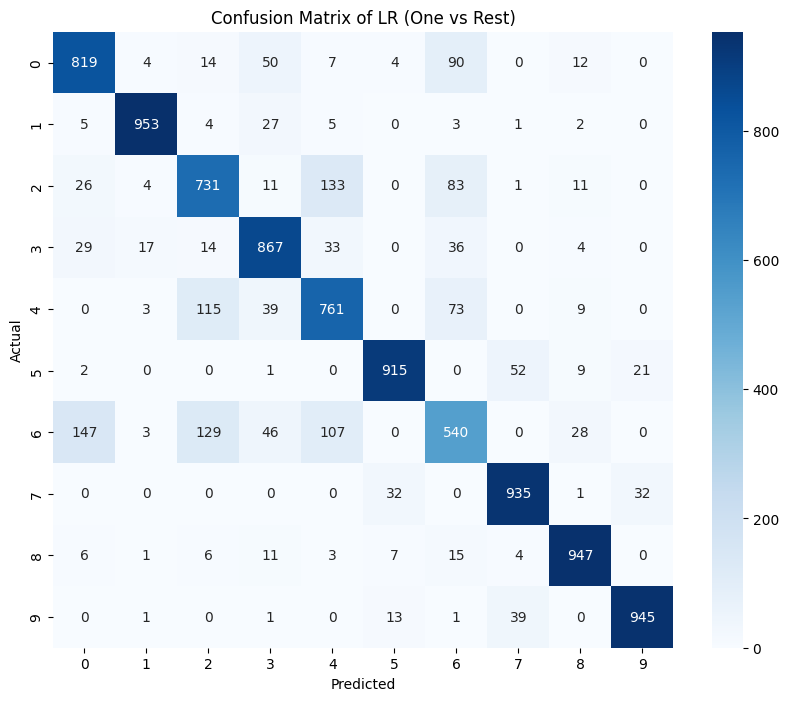

In [ ]:
ovr_model=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_model.fit(train_images, train_labels)
ovr_training_time =time.time()-start

preds = ovr_model.predict(test_images)
pred_ovr = preds

ovr_accuracy = accuracy_score(test_labels,preds)
ovr_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_training_time : .3f}")
print(f"Accuracy : {ovr_accuracy}")
print(f"Precision score : {ovr_precision:} " )
print(f"Recall score: {ovr_recall}")
print(f"F1 score : {ovr_f1_score} ")

# Confusion matrix
ovr_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovr_conf_matrix = cp.asnumpy(ovr_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovr_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs Rest)')
plt.show()

#### **Observation from Score**

#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovr_conf_matrix.shape[0]):
    correct_predictions = ovr_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 953 correctly classified samples.
Class 'Sandal' has 915 correctly classified samples.
Class 'Sneaker' has 935 correctly classified samples.
Class 'Bag' has 947 correctly classified samples.
Class 'Ankle boot' has 945 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (almost similar to sofrmax model)


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(ovr_conf_matrix.shape[0]):
    for predicted_class in range(ovr_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 123 samples
Actual class 'Coat' misclassified as 'Pullover': 114 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 124 samples
Actual class 'Shirt' misclassified as 'Coat': 101 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'

***Similar to the softmax model***

---



### **Logistic Regression (One vs One)**

Training time :  14.941
Accuracy : 0.8503000140190125
Precision score : 0.8489981469712005 
Recall score: 0.8503000000000001
F1 score : 0.8495359746599102 


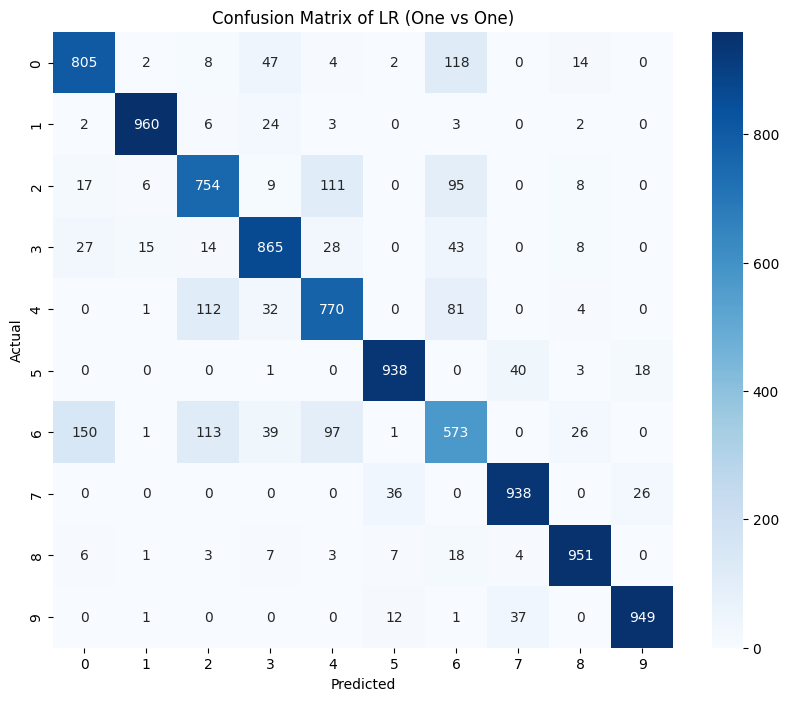

In [ ]:
ovo_model=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovo_model.fit(train_images, train_labels)
ovo_training_time =time.time()-start

preds =ovo_model.predict(test_images)
pred_ovo = preds

ovo_accuracy = accuracy_score(test_labels,preds)
ovo_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_training_time : .3f}")
print(f"Accuracy : {ovo_accuracy}")
print(f"Precision score : {ovo_precision:} " )
print(f"Recall score: {ovo_recall}")
print(f"F1 score : {ovo_f1_score} ")

# Confusion matrix
ovo_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovo_conf_matrix = cp.asnumpy(ovo_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovo_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs One)')
plt.show()

#### **Observation from Score**

#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovo_conf_matrix.shape[0]):
    correct_predictions = ovo_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 960 correctly classified samples.
Class 'Sandal' has 938 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 951 correctly classified samples.
Class 'Ankle boot' has 949 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (similar to the softmax regression model)


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(ovo_conf_matrix.shape[0]):
    for predicted_class in range(ovo_conf_matrix.shape[1]):
        if actual_class != predicted_class and ovo_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 123 samples
Actual class 'Coat' misclassified as 'Pullover': 114 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 124 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'

> Confusion between 'Shirt' and 'Coat' is reduced compared to the previous model (96)


---



### **Comparision**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy],
    'Precision': [softmax_precision, ovr_precision, ovo_precision],
    'Recall': [softmax_recall, ovr_recall, ovo_recall],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score]
}

LR_df = pd.DataFrame(data)

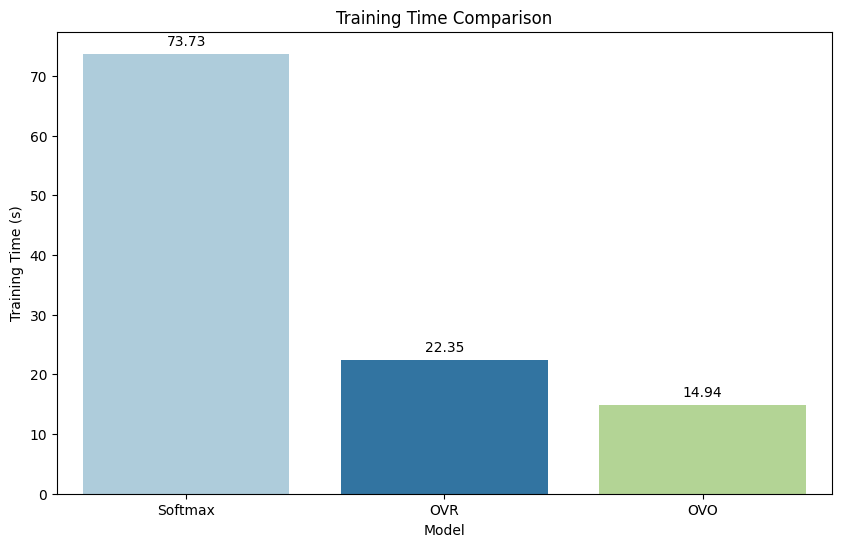

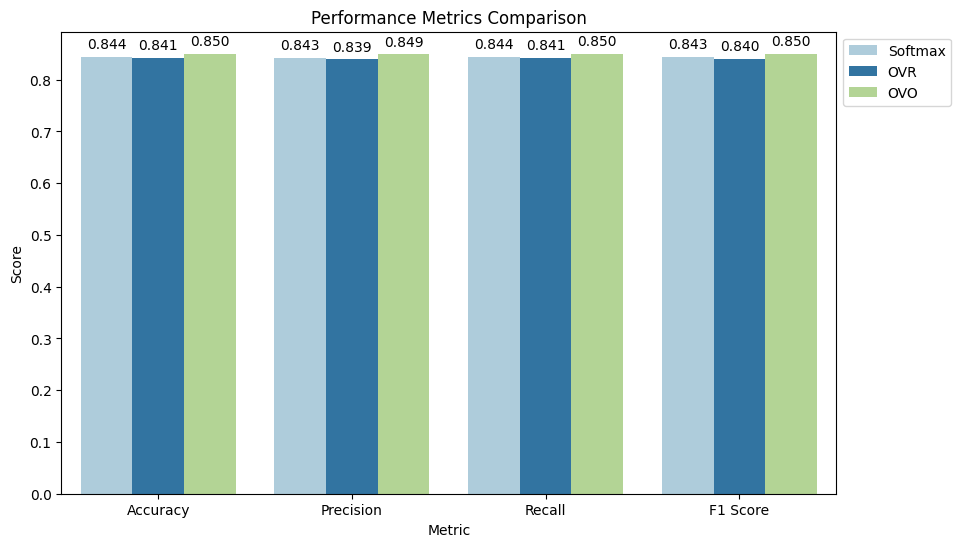

In [ ]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=LR_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = LR_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

* OVO is clearly the most effective model in terms of both training time and performance metrics (accuracy, precision, recall, F1 score).

* Softmax has the longest training time, but its performance results are not significantly better than OVO.

* OVR, while having faster training time than Softmax, is still less effective than OVO in terms of performance metrics.

> **Based on these results, OVO seems to be the best choice for your classification task, as it optimizes both model training time and performance.**


---



## **Support Vector Machine (SVM)**

### **Paramater**

**`penalty: {‘l1’, ‘l2’} (default = ‘l2’)`**
> The regularization term of the target function.

**`loss:{‘squared_hinge’, ‘hinge’} (default = ‘squared_hinge’)`**
> The loss term of the target function.

**`fit_intercept: bool (default = True)`**
> Whether to fit the bias term. Set to False if you expect that the data is already centered.

**`penalized_intercept: bool (default = False)`**
> When true, the bias term is treated the same way as other features; i.e. it’s penalized by the regularization term of the target function. Enabling this feature forces an extra copying the input data X.

**`max_iter: int (default = 1000)`**
> Maximum number of iterations for the underlying solver.

**`linesearch_max_iter: int (default = 100)`**
> Maximum number of linesearch (inner loop) iterations for the underlying (QN) solver.

**`lbfgs_memory: int (default = 5)`**
>Number of vectors approximating the hessian for the underlying QN solver (l-bfgs).

**`C: float (default = 1.0)`**
> The constant scaling factor of the loss term in the target formula:  
$
F(X, y) = \text{penalty}(X) + C \times \text{loss}(X, y)
$

> $C$ is a parameter that adjusts the model's strictness regarding misclassified data points.

> $C$ balances the trade-off between the model's accuracy on the training set and its ability to generalize.

**Gamma (RBF kernel):**
> Affects how data points influence each other in the feature space.

> Gamma adjusts the complexity of the decision boundary in the feature space.


---



### **Linear Kernel**

In [ ]:
# Training SVM witth linear kernel model
svc_linear_model = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model.fit(train_images, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_training_time = end_time - start_time

Training time: 3.77s
Accuracy: 0.8418
Precision: 0.8391
Recall: 0.8418
F1 Score: 0.8393


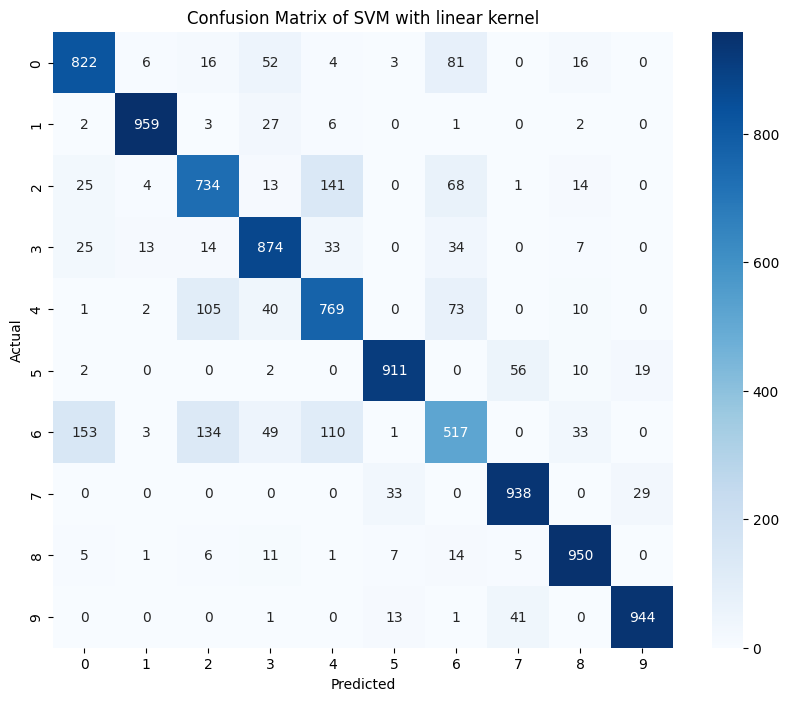

In [ ]:
# Make predictions
test_predictions = svc_linear_model.predict(test_images)
pred_svc_linear = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_accuracy = accuracy_score(test_labels, test_predictions)
svc_linear_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_training_time:.2f}s")
print(f"Accuracy: {svc_linear_accuracy:.4f}")
print(f"Precision: {svc_linear_precision:.4f}")
print(f"Recall: {svc_linear_recall:.4f}")
print(f"F1 Score: {svc_linear_f1:.4f}")

test_predictions = test_predictions.astype('int32')
# Confusion Matrix
svc_linear_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_linear_conf_matrix = cp.asnumpy(svc_linear_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_linear_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with linear kernel')
plt.show()

#### **Observation from Score**

* **Accuracy:** 0.8428: The model predicts correctly 84.28% of the test samples. This is a good result, especially if the data is not imbalanced or has rare classes (we have balanced data on test set)

* **Precision:** 0.8403: 84.03% of the predicted positive samples are true positives. This indicates the model effectively distinguishes between classes and has a low false positive rate.

* **Recall:** 0.8428: The model correctly identifies 84.28% of the actual positive samples, showing it does not miss many true positives.

* **F1 Score:** 0.8404: The F1 Score, the harmonic mean of Precision and Recall, is 84.04%. This reflects a good balance between Precision and Recall.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_linear_conf_matrix.shape[0]):
    correct_predictions = svc_linear_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 959 correctly classified samples.
Class 'Sandal' has 911 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 950 correctly classified samples.
Class 'Ankle boot' has 944 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(svc_linear_conf_matrix.shape[0]):
    for predicted_class in range(svc_linear_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_linear_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_linear_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'Pullover' misclassified as 'Coat': 141 samples
Actual class 'Coat' misclassified as 'Pullover': 105 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 153 samples
Actual class 'Shirt' misclassified as 'Pullover': 134 samples
Actual class 'Shirt' misclassified as 'Coat': 110 samples


**There are 4 pairs of classes that are easily confused:**
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'T-shirt/top'


---



### **RBF kernel**

In [ ]:
# Training SVM with RBF model
svc_RBF_model = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_model.fit(train_images, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_training_time = end_time - start_time

Training time: 21.33s
Accuracy: 0.9015
Precision: 0.9014
Recall: 0.9015
F1 Score: 0.9014


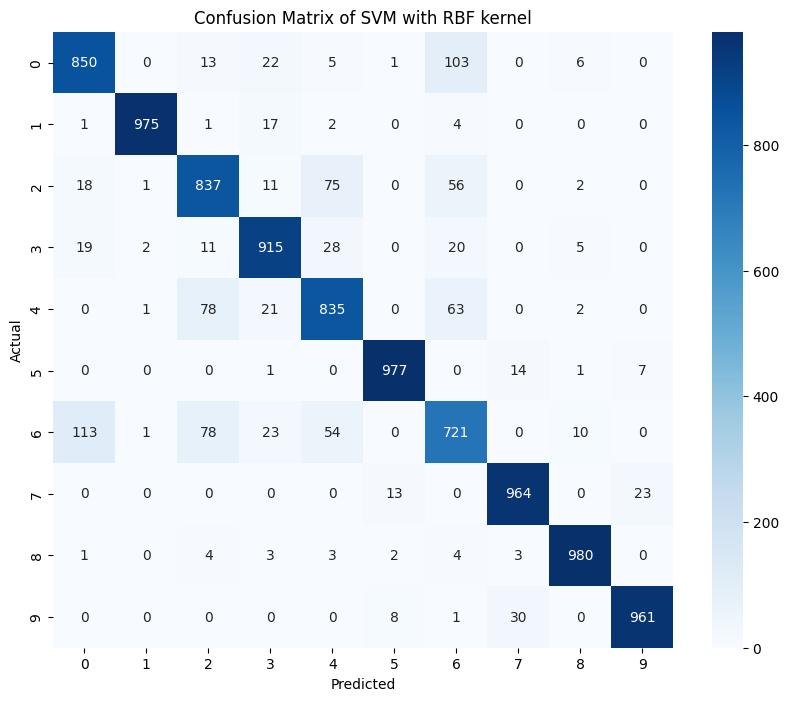

In [ ]:
# Make predictions on test set
test_predictions = svc_RBF_model.predict(test_images)
pred_svc_rbf = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_accuracy = accuracy_score(test_labels, test_predictions)
svc_RBF_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_training_time:.2f}s")
print(f"Accuracy: {svc_RBF_accuracy:.4f}")
print(f"Precision: {svc_RBF_precision:.4f}")
print(f"Recall: {svc_RBF_recall:.4f}")
print(f"F1 Score: {svc_RBF_f1:.4f}")

# Confusion Matrix
svc_RBF_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_RBF_conf_matrix = cp.asnumpy(svc_RBF_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_RBF_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with RBF kernel')
plt.show()

#### **Observation from Score**

* **Accuracy:** 0.9015: An accuracy of 90.15% means the model correctly predicts 90.15% of the test samples. This is an excellent result, especially if the data is not imbalanced or has rare classes. The model demonstrates outstanding performance and high classification accuracy.

* **Precision:** 0.9014:With a precision of 90.14%, 90.14% of the samples predicted as positive are actually positive (true positive + false positive). This indicates the model has an excellent ability to distinguish between classes and has a low false positive rate. Maintaining this level of precision is a positive sign of the model's effectiveness.

* **Recall:** 0.9015:The recall rate is 90.15%, meaning the model correctly identifies 90.15% of the actual positive samples (true positive + false negative). This shows that the model is not only accurate but also highly effective at detecting positive samples, minimizing the number of true positives that are missed. This is a commendable achievement.

* **F1 Score:** 0.9014: An F1 Score of 90.14%, the harmonic mean of Precision and Recall, indicates an excellent balance between these two metrics. A high F1 Score demonstrates that the model not only achieves high accuracy but also has a consistent ability to detect and classify positive samples. This is especially important in real-world applications where both precision and recall are crucial.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_RBF_conf_matrix.shape[0]):
    correct_predictions = svc_RBF_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 975 correctly classified samples.
Class 'Dress' has 915 correctly classified samples.
Class 'Sandal' has 977 correctly classified samples.
Class 'Sneaker' has 964 correctly classified samples.
Class 'Bag' has 980 correctly classified samples.
Class 'Ankle boot' has 961 correctly classified samples.


> Class **'Trouser', 'Dress', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. Notably, the inclusion of **'Dress'** shows improved performance compared to other models, indicating that the model is effectively distinguishing this class as well.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(svc_RBF_conf_matrix.shape[0]):
    for predicted_class in range(svc_RBF_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_RBF_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_RBF_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 103 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 113 samples


> **There is only 1 pairs of classes that are easily confused:** 'T-shirt/top' vs 'Shirt'


---



In [ ]:
# Creating a dataframe with the results
data = {
    'Kernel': ['Linear', 'RBF'],
    'Training Time (s)': [svc_linear_training_time, svc_RBF_training_time],
    'Accuracy': [svc_linear_accuracy, svc_RBF_accuracy],
    'Precision': [svc_linear_precision, svc_RBF_precision],
    'Recall': [svc_linear_recall, svc_RBF_recall],
    'F1 Score': [svc_linear_f1, svc_RBF_f1]
}
SVM_df = pd.DataFrame(data)

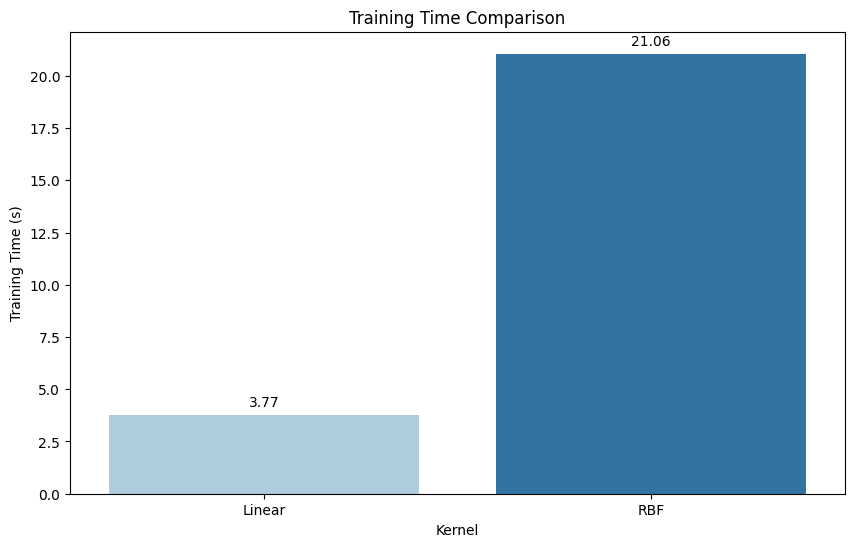

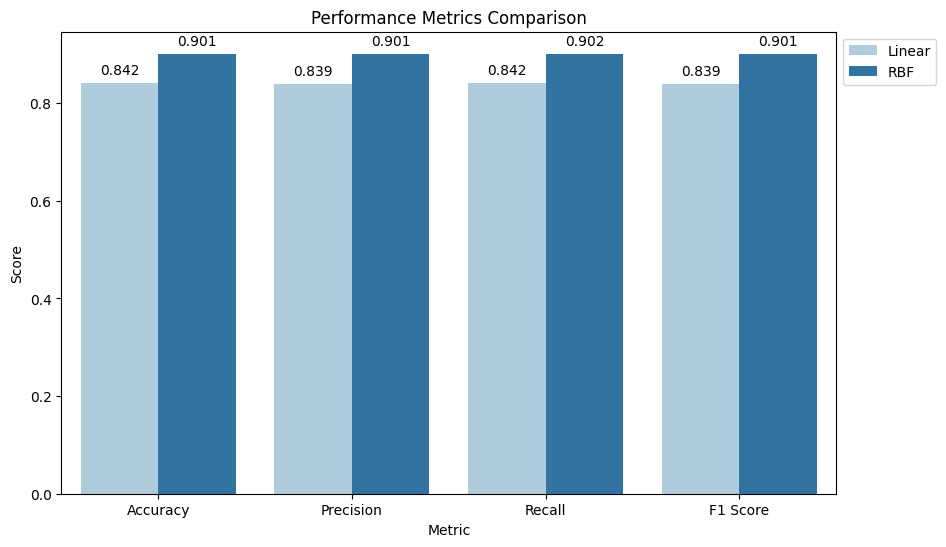

In [ ]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Kernel', y='Training Time (s)', data=SVM_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = SVM_df.melt(id_vars=['Kernel'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Kernel', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

> **The Linear Kernel has a much faster training time compared to the RBF kernel. This may be because the linear kernel only needs to compute a linear separating boundary between classes, whereas the RBF kernel performs nonlinear computations to separate more complex data classes.**

> **The metrics for the RBF kernel are all higher than those for the linear kernel, indicating that the RBF kernel has better classification performance and is more effective at handling complex patterns. We can see that the RBF kernel performs better across all metrics (accuracy, precision, recall, F1 score), making it suitable for applications requiring higher accuracy.**


---



# **Model evaluation**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO', 'Linear kernel SVM', 'RBF kernel SVM'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time, svc_linear_training_time, svc_RBF_training_time, ],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy, svc_RBF_accuracy ],
    'Precision': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision, svc_RBF_precision ],
    'Recall': [softmax_recall, ovr_recall, ovo_recall,svc_linear_recall, svc_RBF_recall ],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1]
}
all_model_df = pd.DataFrame(data)

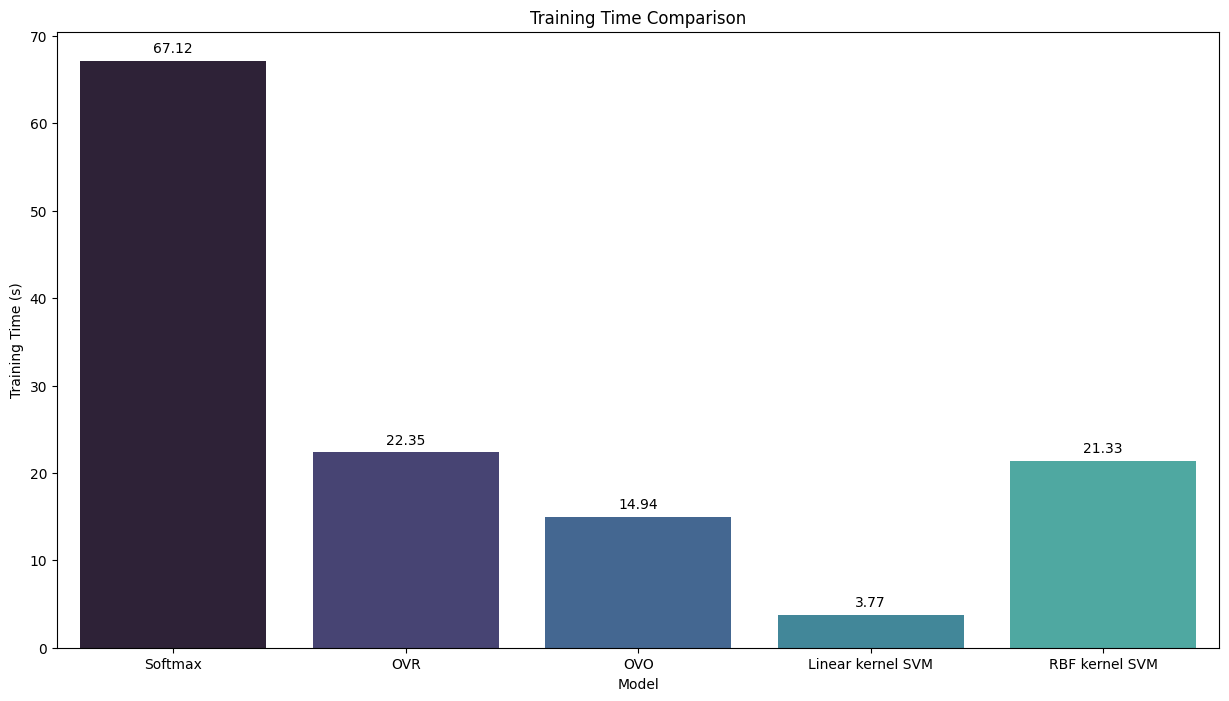

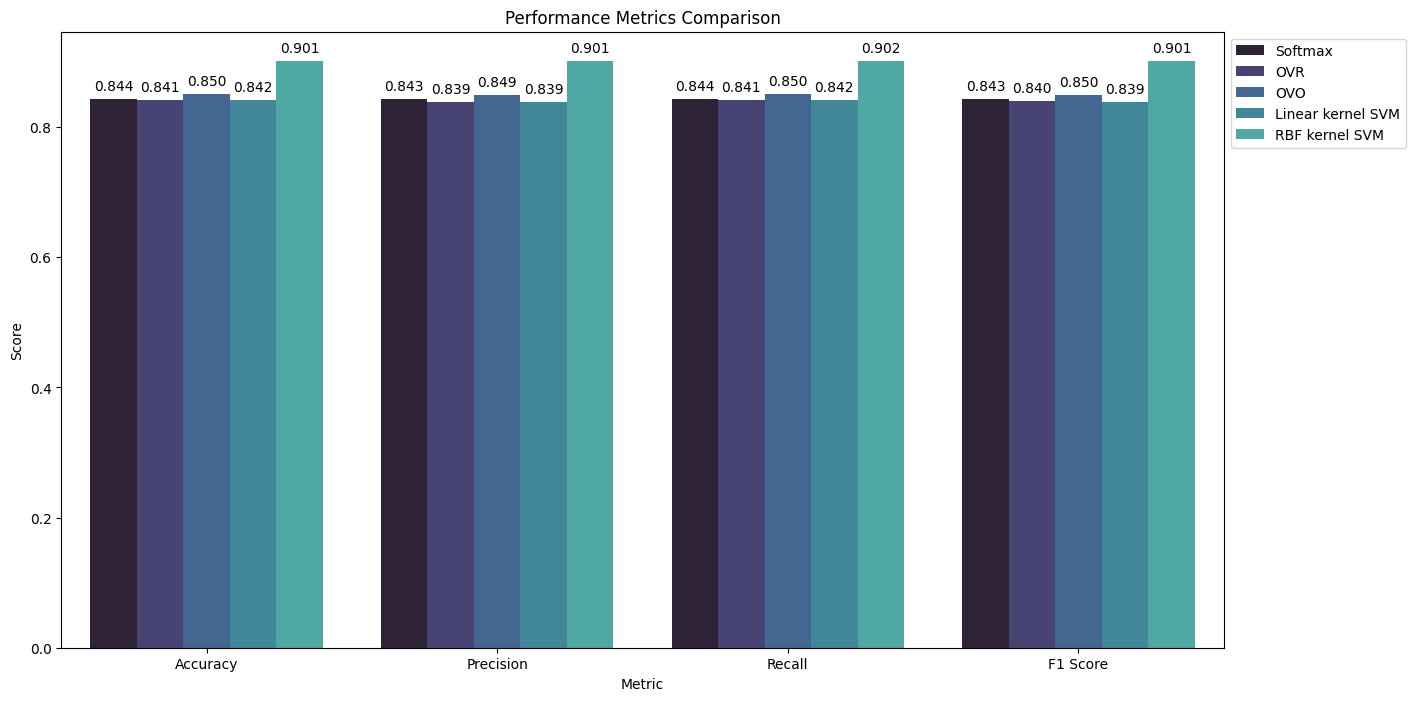

In [ ]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Model', y='Training Time (s)', data=all_model_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = all_model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

**Observations and Evaluation**
> **In terms of runtime, the linear kernel SVM model is much faster than the other models (3.77s). However, its accuracy is almost similar and does not show significant improvement compared to other models (around 84%).**

> **According to the evaluation scores, the RBF model shows a substantial accuracy improvement over the other models (at 90.1%). Although its runtime is considerably higher than linear SVM, it is still at an acceptable level.**

> **The Logistic Regression models (OvO and OvR) produce fairly good results, with accuracies of 85% and 84%, respectively. The OvO model has a shorter runtime due to parallel optimization on the GPU.**

> **Softmax yields results similar to those of the OvO, OvR, and linear kernel SVM models. However, its runtime is significantly longer compared to the average of other models (67.12s), consuming substantial resources even when run on a GPU.**


---



### Visually the Images in Class Pairs are easily confused

In [ ]:
data = {'Softmax': pred_softmax.get(), 'OVR': pred_ovr.get(), 'OVO': pred_ovo.get(), 'Linear kernel': pred_svc_linear.get().astype('int32'), 'RBF kernel': pred_svc_rbf.get(), 'Test label': test_labels.get() }

In [ ]:
df = pd.DataFrame(data)
df

,Softmax,OVR,OVO,Linear kernel,RBF kernel,Test label
0,9,9,9,9,9,9
1,2,2,2,2,2,2
2,1,1,1,1,1,1
3,1,1,1,1,1,1
4,6,6,6,6,6,6
...,...,...,...,...,...,...
9995,9,9,9,9,9,9
9996,1,1,1,1,1,1
9997,6,6,6,6,8,8
9998,1,1,1,1,1,1


> **The SVC model with the RBF kernel has a high accuracy (greater than 90%). There is only one pair of classes that are easily confused in this model, which is 'T-shirt/top' vs 'Shirt'. Therefore, we will only implement it on the remaining models (since the easily confused pairs in the other models also include 'T-shirt/top' vs 'Shirt')**


---



In [ ]:
df = df.drop('RBF kernel', axis=1)

**Class pairs that are easily confused:**
* 'Pullover' vs 'Coat' : 2 vs 4
* 'Shirt' vs 'Coat': 6 vs 4
* 'Shirt' vs 'Pullover': 6 vs 2
* 'Shirt' vs 'T-shirt/top': 6 vs 0


---




#### **'Pullover' vs 'Coat'**

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 2)]

In [ ]:
def showImageClass(df1, df2,  df=test_images.get(), n=5):
    plt.figure(figsize=(10, 10), dpi=150)
    # Get n random indices from df1
    random_indices = np.random.choice(df1.index, n, replace=False)
    random_indices_df2 = np.random.choice(df2.index, n, replace=False)

    for i in range(n):
        plt.subplot(1, n, i + 1)
        index = random_indices[i]
        image_data = df[index].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()
    plt.figure(figsize=(10, 10), dpi=150)
    for i in range(n):
        plt.subplot(2, n, i + 1 + n)
        index2 = random_indices_df2[i]
        image_data2 = df[index2].reshape(28, 28)
        plt.imshow(image_data2, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

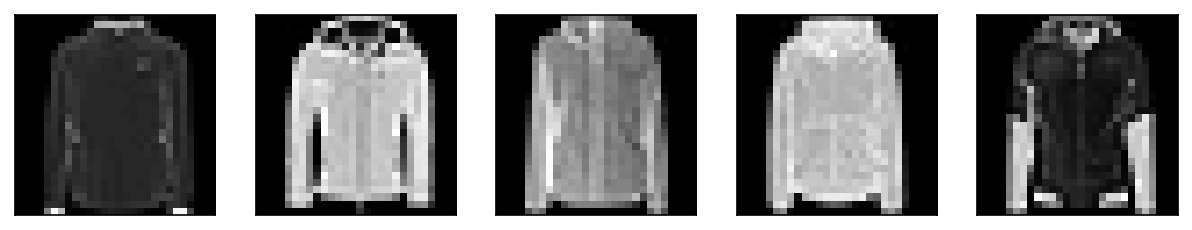

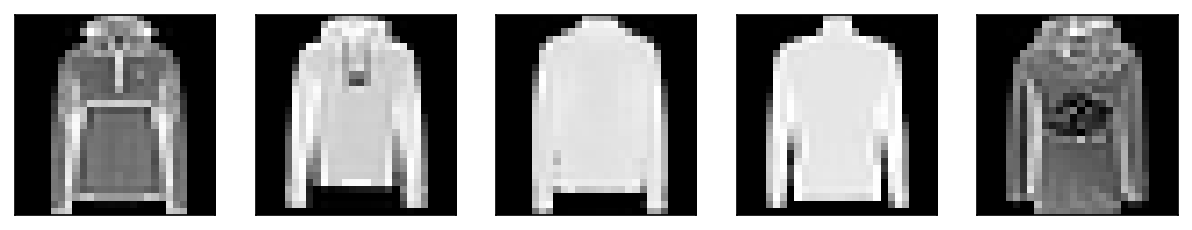

In [ ]:
showImageClass(filtered_df1,filtered_df2)

#### **'Shirt' vs 'Coat'**

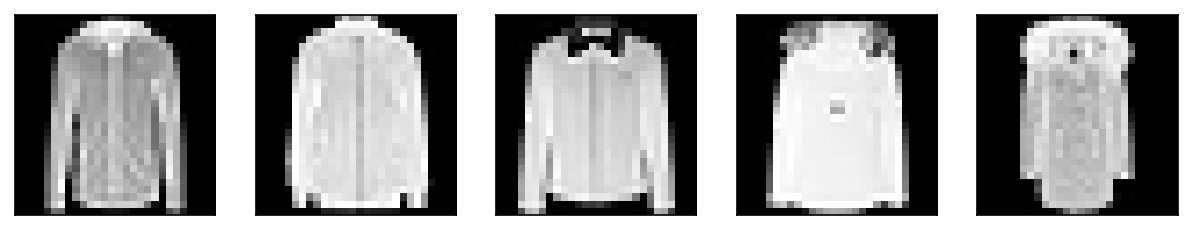

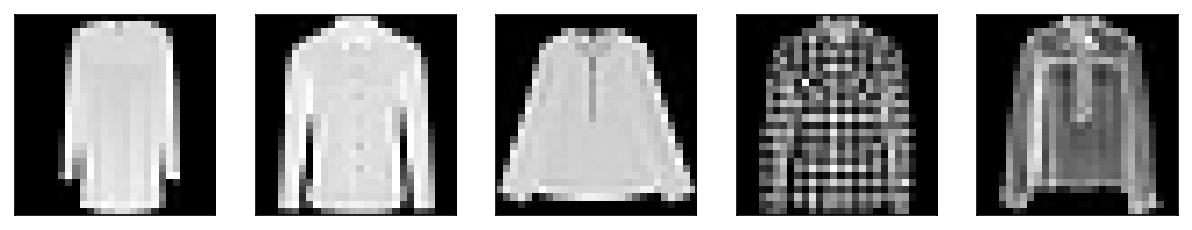

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### **'Shirt'vs 'Pullover'**

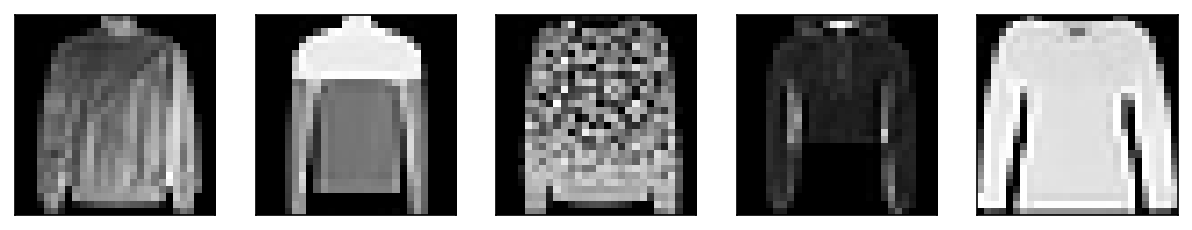

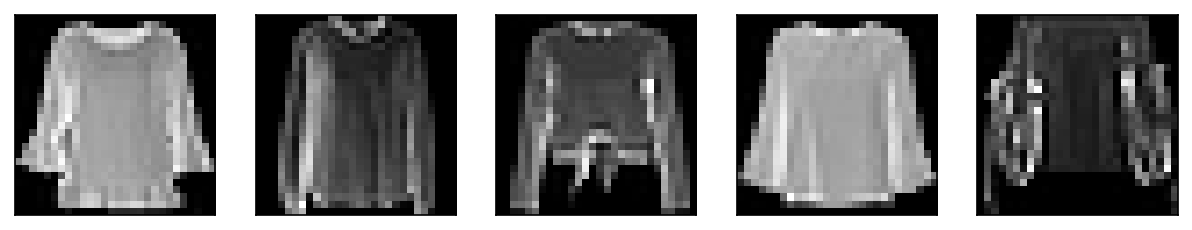

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 2)]
filtered_df2 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### **'Shirt' vs 'T-shirt/top'**

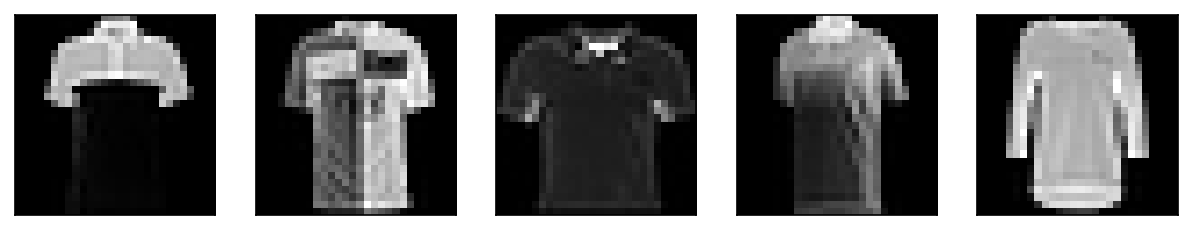

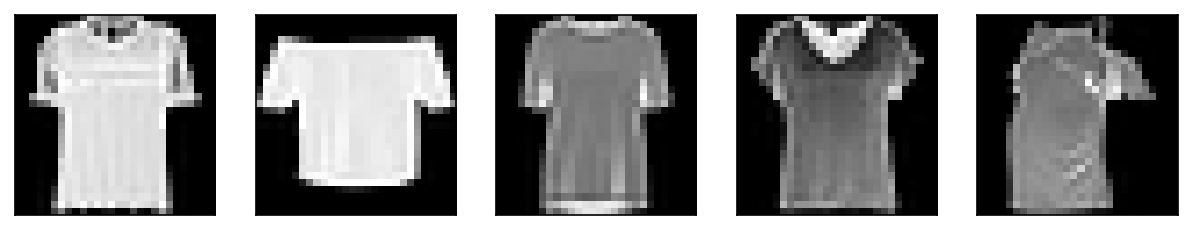

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 0)]
filtered_df2 = df[(df.iloc[:, :4].eq(0).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

> **Based on the visual representations of the images that were misclassified between the classes, we can see a significant similarity in shape. As for the color, since the data consists of black-and-white images, there is a higher chance of similarity among them. Therefore, these models are likely to confuse the classes (the images were randomly selected from the misclassifications of the models).**


---



# **DIMENTIONALITY**